# Elastic Net Regularization: Theory, Geometry & Implementation

## What is Elastic Net?

**Elastic Net** is a hybrid regularization technique that combines the L1 (Lasso) and L2 (Ridge) penalties:

$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \cdot \text{l1\_ratio} \cdot \sum_{j=1}^{p} |\beta_j| + \frac{1}{2} \alpha \cdot (1 - \text{l1\_ratio}) \cdot \sum_{j=1}^{p} \beta_j^2$$

### Why Use Elastic Net?
| Problem | Lasso Behavior | Elastic Net Fix |
|---------|---------------|-----------------|
| **Multicollinearity** | Picks one feature arbitrarily, ignores correlated twins | **Grouping effect**: correlated features get similar coefficients |
| **p > n** | Can select at most n features | Can select more than n features |
| **Many correlated predictors** | Unstable selection | Stable, grouped selection |

### Hyperparameters
- **alpha** ($\alpha \geq 0$): overall regularization strength.
- **l1_ratio** ($0 \leq \text{l1\_ratio} \leq 1$):
  - `0` = pure Ridge (L2)
  - `1` = pure Lasso (L1)
  - `0 < l1_ratio < 1` = mixture of both
  - 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate data with correlated feature groups
n_samples, n_features = 100, 10
X = np.random.randn(n_samples, n_features)

# Group 1: features 0 and 1 are highly correlated
X[:, 1] = X[:, 0] + np.random.randn(n_samples) * 0.1

# Group 2: features 2, 3, 4 are correlated
X[:, 3] = X[:, 2] + np.random.randn(n_samples) * 0.1
X[:, 4] = 0.5 * X[:, 2] + 0.5 * X[:, 3] + np.random.randn(n_samples) * 0.05

# True coefficients: note that group members have non-zero true values
true_coef = np.array([2.0, -2.0, 1.5, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, -1.0])
noise = np.random.randn(n_samples) * 1.5
y = X @ true_coef + noise

# Center data
X_mean = X.mean(axis=0)
y_mean = y.mean()
Xc = X - X_mean
yc = y - y_mean

colors = plt.cm.tab10(np.linspace(0, 1, n_features))

print("Data shape:", X.shape)
print("True non-zero coefficients at indices:", np.where(true_coef != 0)[0])
print("Correlation matrix (first 5 features):")
print(np.round(np.corrcoef(X[:, :5].T), 2))


Data shape: (100, 10)
True non-zero coefficients at indices: [0 1 2 4 9]
Correlation matrix (first 5 features):
[[1.   0.99 0.06 0.08 0.07]
 [0.99 1.   0.06 0.07 0.06]
 [0.06 0.06 1.   0.99 1.  ]
 [0.08 0.07 0.99 1.   1.  ]
 [0.07 0.06 1.   1.   1.  ]]


## 1. Coordinate Descent for Elastic Net

Because the objective is convex but only piecewise-differentiable (due to the L1 term), we use **coordinate descent**: cycle through each coefficient and apply a closed-form update.

### Update Rule for Coordinate $j$
Let $r_j = y - X\beta + \beta_j X_j$ be the partial residual.

$$\rho_j = \frac{1}{n} X_j^T r_j$$

$$\beta_j = \frac{S\big(\rho_j, \alpha \cdot \text{l1\_ratio}\big)}{\frac{1}{n}||X_j||^2 + \alpha \cdot (1 - \text{l1\_ratio})}$$

where $S(z, \gamma) = \text{sign}(z) \cdot \max(|z| - \gamma, 0)$ is the soft-thresholding operator.

The denominator shows the **L2 component** stabilizing the update, while the **L1 component** in the numerator drives sparsity.


In [8]:
def elastic_net_cd(X, y, alpha, l1_ratio, max_iter=3000, tol=1e-4):
    """
    Elastic Net via coordinate descent.
    Objective: (1/(2n)) * ||y - Xw||^2 
               + alpha * l1_ratio * ||w||_1 
               + 0.5 * alpha * (1 - l1_ratio) * ||w||_2^2
    """
    n, p = X.shape
    w = np.zeros(p)
    z = np.sum(X**2, axis=0) / n
    l1_term = alpha * l1_ratio
    l2_term = alpha * (1.0 - l1_ratio)
    
    for iteration in range(max_iter):
        w_old = w.copy()
        for j in range(p):
            residual = y - X @ w + w[j] * X[:, j]
            rho = np.dot(X[:, j], residual) / n
            denom = z[j] + l2_term
            w[j] = np.sign(rho) * max(abs(rho) - l1_term, 0.0) / denom
        if np.max(np.abs(w - w_old)) < tol:
            break
    
    return w


# Quick sanity check
alpha_test = 0.2
l1_test = 0.5
w_test = elastic_net_cd(Xc, yc, alpha_test, l1_test)
print("Elastic Net coefficients (alpha=0.2, l1_ratio=0.5):")
print(np.round(w_test, 4))
print("Non-zero count:", np.sum(np.abs(w_test) > 1e-4))


Elastic Net coefficients (alpha=0.2, l1_ratio=0.5):
[-0.     -0.0191  0.6557  0.5997  0.6091  0.1071 -0.0124 -0.      0.
 -0.7498]
Non-zero count: 7


## 2. The Grouping Effect

When features are highly correlated, Lasso tends to select one arbitrarily and drive the others to exactly zero. This is unstable: a small change in data might switch which feature is selected.

**Elastic Net solves this via the grouping effect**: the L2 component forces correlated features to share coefficient magnitude. If two features $X_j$ and $X_k$ are identical, Elastic Net gives them equal coefficients (whereas Lasso gives all mass to one).

The bar chart below compares Lasso, Ridge, and Elastic Net on our correlated dataset. Notice how Elastic Net assigns non-zero values to *both* members of a correlated group, similar to Ridge, while still zeroing out irrelevant features like Lasso.


=== Grouping Effect Demo ===
Group 1 (features 0 & 1, highly correlated):
  True:  [2.000, -2.000]
  Lasso: [-0.000, -0.000]
  Ridge: [-0.058, -0.098]
  ENet:  [-0.000, -0.019]

Sparsity (non-zero coefficients):
  Lasso:       3
  Ridge:       10
  ElasticNet:  7


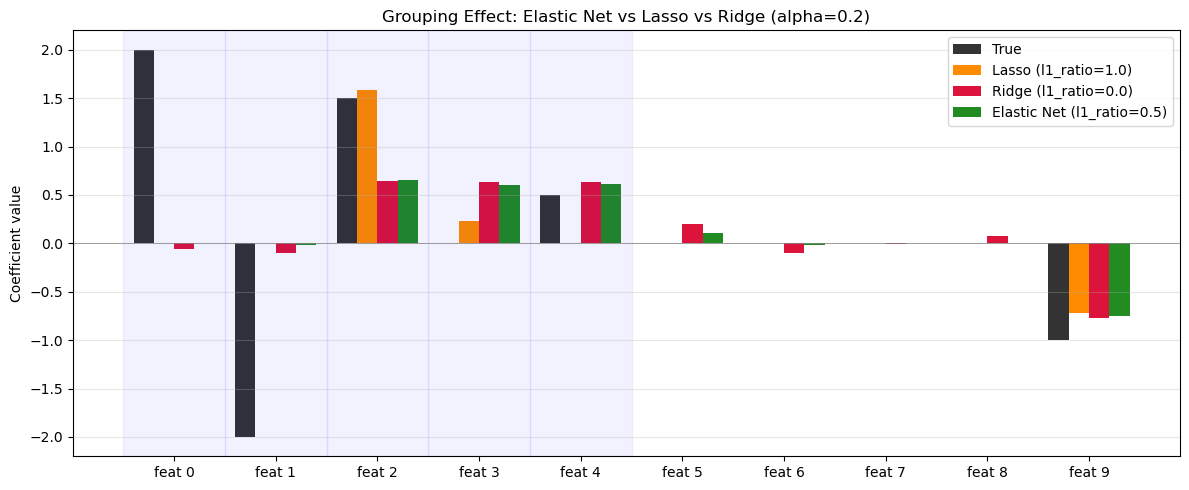

In [9]:
alpha_group = 0.2

w_lasso = elastic_net_cd(Xc, yc, alpha_group, 1.0)
w_ridge = elastic_net_cd(Xc, yc, alpha_group, 0.0)
w_enet = elastic_net_cd(Xc, yc, alpha_group, 0.5)

print("=== Grouping Effect Demo ===")
print("Group 1 (features 0 & 1, highly correlated):")
print("  True:  [{0:.3f}, {1:.3f}]".format(true_coef[0], true_coef[1]))
print("  Lasso: [{0:.3f}, {1:.3f}]".format(w_lasso[0], w_lasso[1]))
print("  Ridge: [{0:.3f}, {1:.3f}]".format(w_ridge[0], w_ridge[1]))
print("  ENet:  [{0:.3f}, {1:.3f}]".format(w_enet[0], w_enet[1]))
print()
print("Sparsity (non-zero coefficients):")
print("  Lasso:      ", np.sum(np.abs(w_lasso) > 1e-4))
print("  Ridge:      ", np.sum(np.abs(w_ridge) > 1e-4))
print("  ElasticNet: ", np.sum(np.abs(w_enet) > 1e-4))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(n_features)
width = 0.2

ax.bar(x_pos - 1.5*width, true_coef, width, label='True', color='black', alpha=0.8)
ax.bar(x_pos - 0.5*width, w_lasso, width, label='Lasso (l1_ratio=1.0)', color='darkorange')
ax.bar(x_pos + 0.5*width, w_ridge, width, label='Ridge (l1_ratio=0.0)', color='crimson')
ax.bar(x_pos + 1.5*width, w_enet, width, label='Elastic Net (l1_ratio=0.5)', color='forestgreen')

# Highlight correlated groups
for g in [0, 1, 2, 3, 4]:
    ax.axvspan(g - 0.5, g + 0.5, alpha=0.05, color='blue')

ax.set_xticks(x_pos)
ax.set_xticklabels(['feat ' + str(i) for i in range(n_features)])
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Coefficient value')
ax.set_title('Grouping Effect: Elastic Net vs Lasso vs Ridge (alpha=' + str(alpha_group) + ')')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 3. Geometric Intuition: The Constraint Region

Regularization can be viewed as minimizing RSS subject to a penalty budget:

$$\alpha \cdot \text{l1\_ratio} \cdot \sum |\beta_j| + \frac{1}{2} \alpha \cdot (1 - \text{l1\_ratio}) \cdot \sum \beta_j^2 \leq t$$

The feasible region's shape determines the solution:

- **L1 (l1_ratio=1)**: A diamond. Sharp corners touch the axes → sparsity.
- **L2 (l1_ratio=0)**: A circle. Smooth boundary → no sparsity, uniform shrinkage.
- **Elastic Net (0 < l1_ratio < 1)**: A rounded diamond. It has **corners** (promoting sparsity) but also **curved edges** (grouping correlated coefficients).

The plot below shows the unit-level sets of the penalty functions in 2D coefficient space.


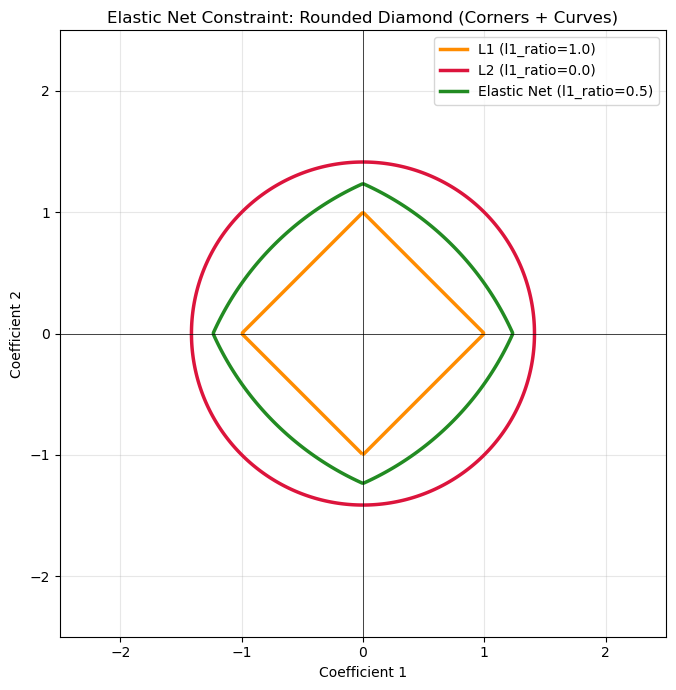

In [10]:
from matplotlib.lines import Line2D

w1 = np.linspace(-2.5, 2.5, 400)
w2 = np.linspace(-2.5, 2.5, 400)
W1, W2 = np.meshgrid(w1, w2)

# Penalty = 1 level sets (with alpha=1)
L1_pen = 1.0 * (np.abs(W1) + np.abs(W2)) + 0.0
L2_pen = 0.0 + 0.5 * 1.0 * (W1**2 + W2**2)
EN_pen = 0.5 * (np.abs(W1) + np.abs(W2)) + 0.25 * (W1**2 + W2**2)

fig, ax = plt.subplots(figsize=(7, 7))

ax.contour(W1, W2, L1_pen, levels=[1], colors='darkorange', linewidths=2.5)
ax.contour(W1, W2, L2_pen, levels=[1], colors='crimson', linewidths=2.5)
ax.contour(W1, W2, EN_pen, levels=[1], colors='forestgreen', linewidths=2.5)

legend_elements = [
    Line2D([0], [0], color='darkorange', lw=2.5, label='L1 (l1_ratio=1.0)'),
    Line2D([0], [0], color='crimson', lw=2.5, label='L2 (l1_ratio=0.0)'),
    Line2D([0], [0], color='forestgreen', lw=2.5, label='Elastic Net (l1_ratio=0.5)')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('Coefficient 1')
ax.set_ylabel('Coefficient 2')
ax.set_title('Elastic Net Constraint: Rounded Diamond (Corners + Curves)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Regularization Paths at Different l1_ratios

As $\alpha$ increases, the coefficient paths evolve differently depending on the l1_ratio:

- **Low l1_ratio (near Ridge)**: smooth shrinkage, no exact zeros, correlated features share load.
- **High l1_ratio (near Lasso)**: aggressive sparsity, but unstable with correlated groups.
- **Balanced l1_ratio (e.g., 0.5)**: a compromise — some features zero out, but correlated groups survive together.

The plots below show paths for three different l1_ratio values.


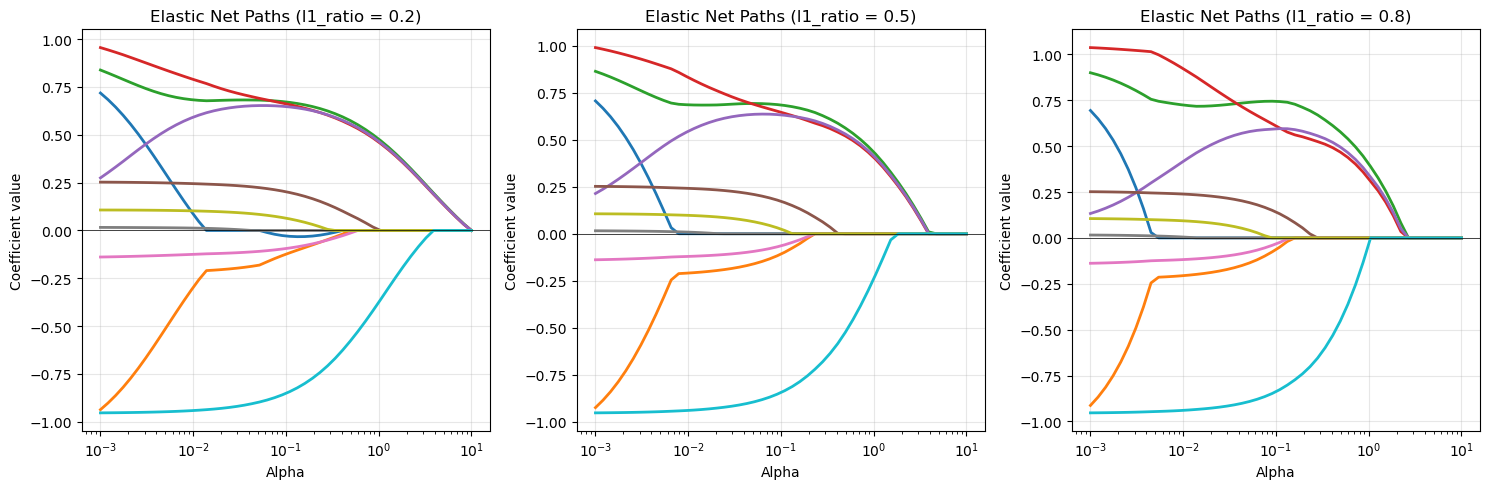

In [11]:
alphas = np.logspace(-3, 1, 50)
l1_ratios = [0.2, 0.5, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, l1_r in enumerate(l1_ratios):
    ax = axes[idx]
    paths = np.zeros((len(alphas), n_features))
    for i, a in enumerate(alphas):
        paths[i] = elastic_net_cd(Xc, yc, a, l1_r)
    
    for j in range(n_features):
        ax.plot(alphas, paths[:, j], color=colors[j], linewidth=2,
                label='feat ' + str(j))
    ax.set_xscale('log')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Coefficient value')
    ax.set_title('Elastic Net Paths (l1_ratio = ' + str(l1_r) + ')')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Hyperparameter Tuning: Alpha vs L1 Ratio

Elastic Net has **two** hyperparameters, creating a 2D search space. We tune them by monitoring validation error on a held-out set.

The heatmap below shows validation MSE across a grid of alpha (rows) and l1_ratio (columns). The optimal model sits at the minimum of this surface — typically where the model is sparse enough to avoid overfitting, but not so regularized that it underfits.

In practice, use **cross-validation** (e.g., scikit-learn's `ElasticNetCV`) to search this grid efficiently.


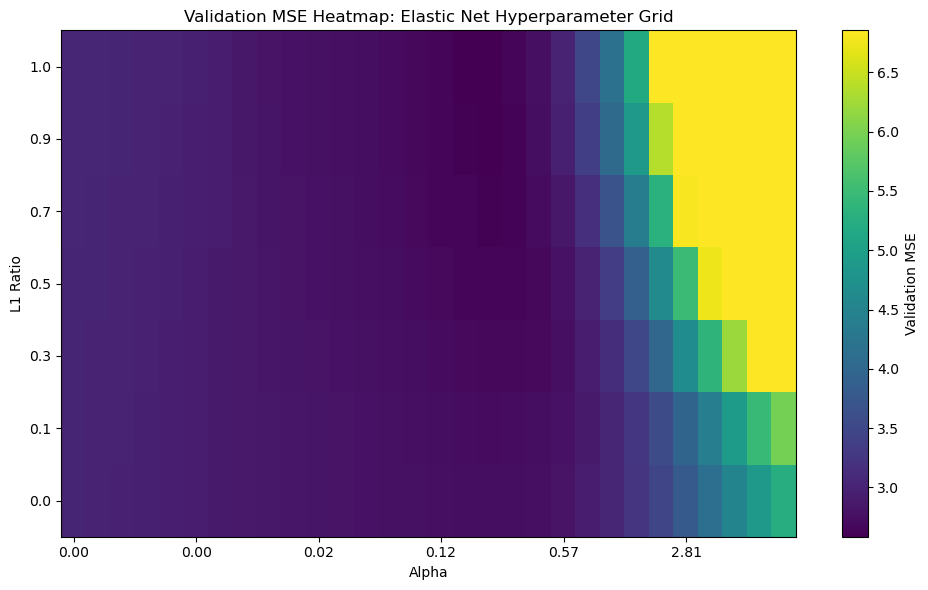

Best l1_ratio: 1.0
Best alpha:    0.2212
Best val MSE:  2.5831


In [12]:
# Train / validation split
split = int(0.7 * n_samples)
X_train, X_val = Xc[:split], Xc[split:]
y_train, y_val = yc[:split], yc[split:]

alphas_grid = np.logspace(-3, 1, 30)
l1_ratios_grid = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

val_mse_grid = np.zeros((len(l1_ratios_grid), len(alphas_grid)))

for i, l1_r in enumerate(l1_ratios_grid):
    for j, a in enumerate(alphas_grid):
        w = elastic_net_cd(X_train, y_train, a, l1_r)
        val_mse_grid[i, j] = np.mean((X_val @ w - y_val)**2)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(val_mse_grid, aspect='auto', cmap='viridis', origin='lower')
ax.set_xticks(range(0, len(alphas_grid), 5))
ax.set_xticklabels(['{0:.2f}'.format(a) for a in alphas_grid[::5]])
ax.set_yticks(range(len(l1_ratios_grid)))
ax.set_yticklabels(['{0:.1f}'.format(r) for r in l1_ratios_grid])
ax.set_xlabel('Alpha')
ax.set_ylabel('L1 Ratio')
ax.set_title('Validation MSE Heatmap: Elastic Net Hyperparameter Grid')
fig.colorbar(im, ax=ax, label='Validation MSE')
plt.tight_layout()
plt.show()

# Best hyperparameters
best_idx = np.unravel_index(np.argmin(val_mse_grid), val_mse_grid.shape)
best_l1 = l1_ratios_grid[best_idx[0]]
best_alpha = alphas_grid[best_idx[1]]
print("Best l1_ratio: {0:.1f}".format(best_l1))
print("Best alpha:    {0:.4f}".format(best_alpha))
print("Best val MSE:  {0:.4f}".format(val_mse_grid[best_idx]))


## 6. Practical Comparison

At a fixed moderate regularization strength, the differences between methods are clear:

- **OLS** overfits, assigning noise to irrelevant features.
- **Lasso** aggressively zeros out features, but may arbitrarily exclude one member of a correlated pair.
- **Ridge** keeps all features, shrinking them proportionally — no feature selection.
- **Elastic Net** selects irrelevant features out (like Lasso) while keeping correlated groups together (like Ridge).

The bar chart below uses the validation-optimal alpha for Elastic Net to ensure a fair comparison.


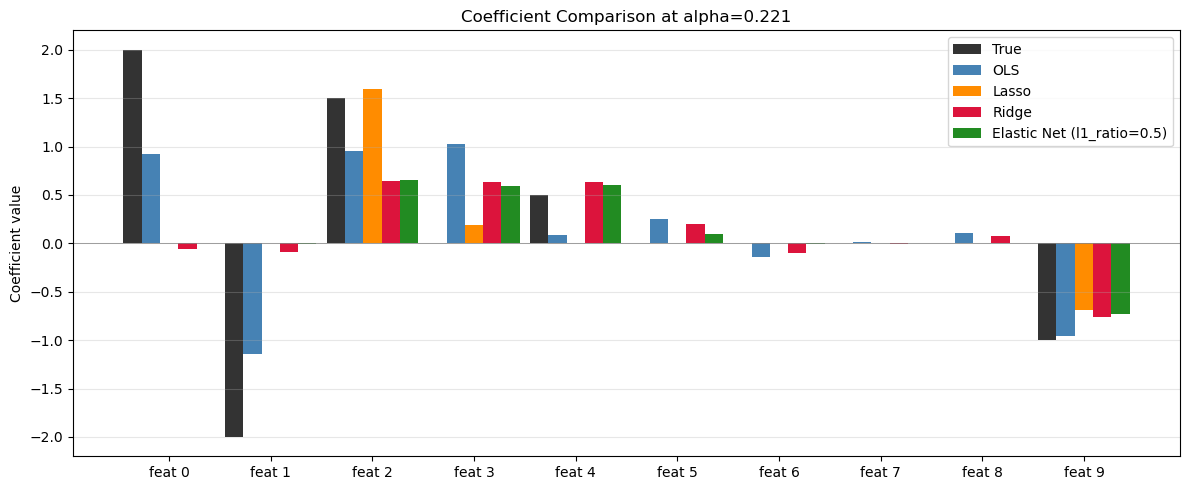

Non-zero counts:
  OLS:         10
  Lasso:       3
  Ridge:       10
  ElasticNet:  7


In [13]:
alpha_comp = best_alpha if 'best_alpha' in vars() else 0.3
l1_comp = 0.5

w_ols = np.linalg.lstsq(Xc, yc, rcond=None)[0]
w_lasso = elastic_net_cd(Xc, yc, alpha_comp, 1.0)
w_ridge = elastic_net_cd(Xc, yc, alpha_comp, 0.0)
w_enet = elastic_net_cd(Xc, yc, alpha_comp, l1_comp)

x_pos = np.arange(n_features)
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 2.0*width, true_coef, width, label='True', color='black', alpha=0.8)
ax.bar(x_pos - 1.0*width, w_ols, width, label='OLS', color='steelblue')
ax.bar(x_pos, w_lasso, width, label='Lasso', color='darkorange')
ax.bar(x_pos + 1.0*width, w_ridge, width, label='Ridge', color='crimson')
ax.bar(x_pos + 2.0*width, w_enet, width,
       label='Elastic Net (l1_ratio=' + str(l1_comp) + ')', color='forestgreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(['feat ' + str(i) for i in range(n_features)])
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Comparison at alpha=' + '{0:.3f}'.format(alpha_comp))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Non-zero counts:")
print("  OLS:        ", np.sum(np.abs(w_ols) > 1e-4))
print("  Lasso:      ", np.sum(np.abs(w_lasso) > 1e-4))
print("  Ridge:      ", np.sum(np.abs(w_ridge) > 1e-4))
print("  ElasticNet: ", np.sum(np.abs(w_enet) > 1e-4))


## Summary

| Property | OLS | Lasso (L1) | Ridge (L2) | Elastic Net |
|----------|-----|------------|------------|-------------|
| **Sparsity** | No | Yes | No | Yes |
| **Closed-form solution** | Yes | No | Yes | No |
| **Handles multicollinearity** | Poor | Poor | Excellent | Excellent |
| **Grouping effect** | No | No | Yes | Yes |
| **Feature selection** | No | Yes | No | Yes |
| **Max features selected** | All | $\leq n$ | All | All |
| **Hyperparameters** | None | Alpha | Alpha | Alpha + l1_ratio |

### When to Use Elastic Net
1. **You have correlated features** and want stable, interpretable groups rather than arbitrary Lasso selection.
2. **You want sparsity** but Lasso is unstable or selects too few features.
3. **You don't know** whether L1 or L2 is better — Elastic Net lets the data decide via cross-validation.

### Key Takeaways
- The **L1 component** provides sparsity and feature selection.
- The **L2 component** provides the grouping effect and numerical stability.
- The **l1_ratio** is the dial between selection and grouping; it is usually tuned via cross-validation along with alpha.
- 